# Lib

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Data

In [4]:
df_target = pd.read_csv("../../data/github_social_network/musae_git_target.csv")
df_target.columns = df_target.columns.str.strip().str.lower().str.replace(" ", "_")

with open("../../data/github_social_network/musae_git_features.json", "r") as f:
    features_json = json.load(f)

In [5]:
print(f"Mapping labels for {len(df_target)} users.")
print(f"Mapping features for {len(features_json)} users.")

Mapping labels for 37700 users.
Mapping features for 37700 users.


# Label Distribution

# Feature Space Analysis

In [13]:
feature_lengths = [len(feats) for feats in features_json.values()]

print("Khối lượng đặc trưng của mỗi lập trình viên:")
print(f"\tTrung bình mỗi người có       : {sum(feature_lengths)/len(feature_lengths):.2f} đặc trưng")
print(f"\tSố lượng đặc trưng nhiều nhất : {max(feature_lengths)}")
print(f"\tSố lượng đặc trưng ít nhất    : {min(feature_lengths)}")

Khối lượng đặc trưng của mỗi lập trình viên:
	Trung bình mỗi người có       : 18.31 đặc trưng
	Số lượng đặc trưng nhiều nhất : 42
	Số lượng đặc trưng ít nhất    : 8


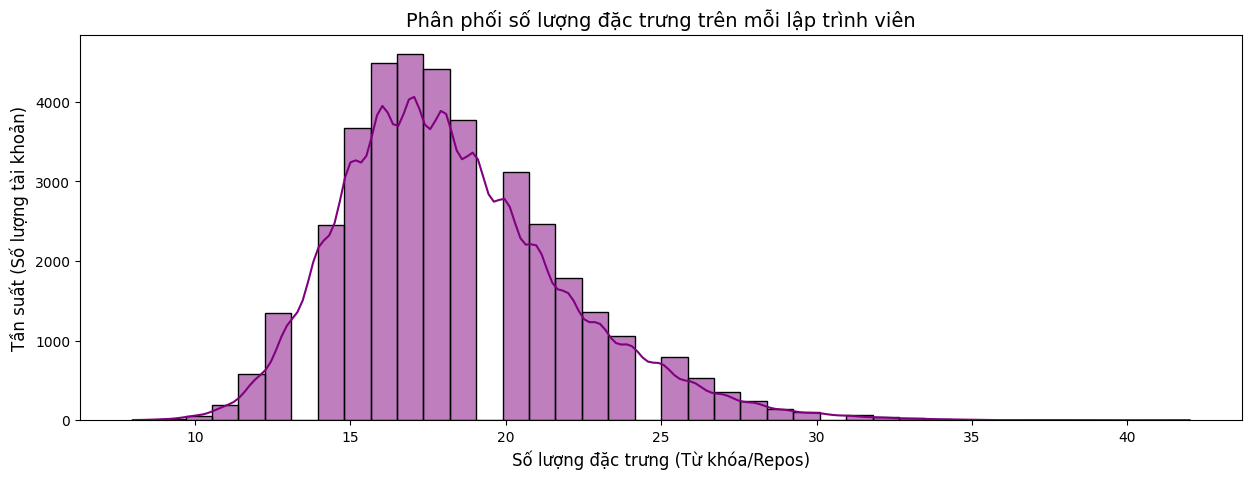

In [17]:
plt.figure(figsize=(15, 5))
sns.histplot(feature_lengths, bins=40, color='purple', kde=True)
plt.title('Phân phối số lượng đặc trưng trên mỗi lập trình viên', fontsize=14)
plt.xlabel('Số lượng đặc trưng (Từ khóa/Repos)', fontsize=12)
plt.ylabel('Tần suất (Số lượng tài khoản)', fontsize=12)
plt.show()

Tổng số lượng Feature ID độc lập (Unique Features) trong toàn mạng: 4005
Đây sẽ là kích thước số chiều của vector đặc trưng cho mỗi Node khi đưa vào mô hình học máy.


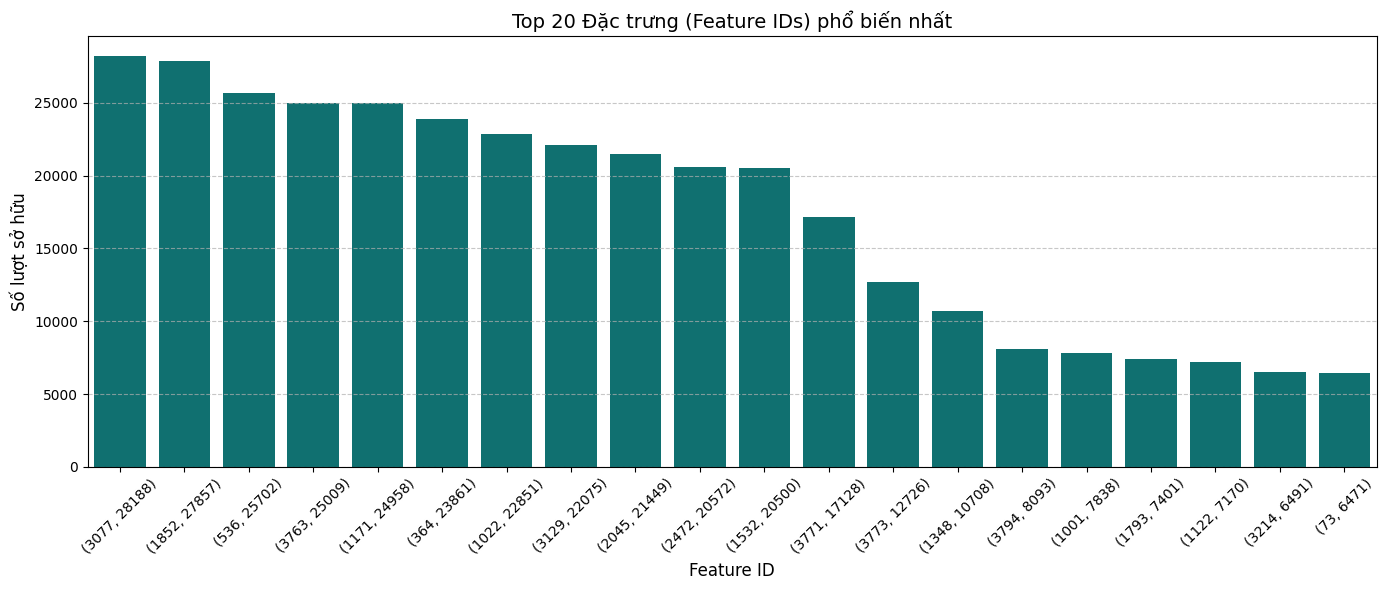

In [18]:
# Gom toàn bộ các feature ID từ tất cả user vào một list phẳng (flat list)
all_features = []
for feats in features_json.values():
    all_features.extend(feats)

# Đếm tần suất xuất hiện của từng Feature ID
feature_counts = Counter(all_features)
total_unique_features = len(feature_counts)

print(f"Tổng số lượng Feature ID độc lập (Unique Features) trong toàn mạng: {total_unique_features}")
print("Đây sẽ là kích thước số chiều của vector đặc trưng cho mỗi Node khi đưa vào mô hình học máy.")

# Lấy top 20 feature phổ biến nhất
top_20_features = feature_counts.most_common(20)
top_20_ids = [str(item) for item in top_20_features]
top_20_freq = [item[1] for item in top_20_features]

# Trực quan hóa
plt.figure(figsize=(14, 6))
sns.barplot(x=top_20_ids, y=top_20_freq, color='teal')
plt.title('Top 20 Đặc trưng (Feature IDs) phổ biến nhất', fontsize=14)
plt.xlabel('Feature ID', fontsize=12)
plt.ylabel('Số lượt sở hữu', fontsize=12)
plt.xticks(rotation=45)

# Thêm lưới trục y để dễ nhìn
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()